# EPL Match Prediction — a working miniature of the WC2026 pipeline

**Dataset**: English Premier League 2022-23 → 2024-25 (1,140 matches) from
[football-data.co.uk](https://www.football-data.co.uk) — the canonical public football
results CSV, bundled locally at `data/epl_matches.csv`. It includes Bet365 closing 1X2
odds, which gives us the same thing the real project prices against: a **de-viggable
market baseline**.

**Pipeline mirrored from the repo** (`wc2026`):

| This notebook | Real project module |
|---|---|
| cleaning contract | `ingest/` + `pit.py` |
| time-based split | PIT gate (no leakage) |
| Poisson attack/defence model | `models/dixon_coles.py` family |
| de-vigged market | `models/market_implied.py`, `features/market_fv.py` |
| blend ensemble | `models/meta_ensemble.py` |
| log loss / Brier / RPS + bootstrap CI + Diebold-Mariano | `eval/metrics.py` |
| calibration reliability with Wilson CIs | terminal `ReliabilityChart` |
| edge-threshold betting sim | `pricing/` + the stay-flat `min_edge` fence |

**Honesty rules in force** (same as the terminal): every aggregate wears its `n`;
every score wears an interval; calibration bins show their counts; axes are never
truncated to flatter a curve; and the conclusion is whatever the statistics say.

Run with: `uv run --with matplotlib --with jupyter jupyter lab notebooks/epl_prediction.ipynb`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEED = 20260611  # WC2026 opening day, same fixed seed convention as the repo
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.0 | pandas 3.0.3


## 1. Load — with provenance

The first thing the real terminal shows for any number is *where it came from and how
fresh it is*. We do the notebook equivalent: source, shape, date range, and the exact
columns we intend to use, before anything else touches the frame.

In [2]:
# Season looks numeric ("2223") but is a label; without an explicit dtype,
# read_csv coerces it to int and every string comparison silently matches
# nothing. Schema-on-read beats debugging an empty frame two sections later.
df = pd.read_csv("data/epl_matches.csv", dtype={"Season": str})
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date").reset_index(drop=True)

print("source        : football-data.co.uk (E0), seasons 2022-23 .. 2024-25")
print(f"matches (n)   : {len(df)}")
print(f"date range    : {df['Date'].min().date()} .. {df['Date'].max().date()}")
print(f"teams         : {df['HomeTeam'].nunique()}")
print(f"columns       : {list(df.columns)}")
df.head(3)

source        : football-data.co.uk (E0), seasons 2022-23 .. 2024-25
matches (n)   : 1140
date range    : 2022-08-05 .. 2025-05-25
teams         : 24
columns       : ['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A']


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A
0,2223,2022-08-05,Crystal Palace,Arsenal,0,2,A,4.20,3.6,1.85
1,2223,2022-08-06,Fulham,Liverpool,2,2,D,11.00,6.0,1.25
2,2223,2022-08-06,Bournemouth,Aston Villa,2,0,H,3.75,3.5,2.00


## 2. Cleaning contract

Cleaning is a set of **checks that must pass**, not silent coercions. Each check prints
its verdict; a failure here should stop the analysis, not be papered over.
(The real project enforces this shape of discipline in `pit.py` and the ingest
validators.)

In [3]:
issues = []

# 2.1 completeness: the columns we model with must be fully populated
required = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "B365H", "B365D", "B365A"]
nulls = df[required].isna().sum()
if nulls.sum() > 0:
    issues.append(f"nulls found:\n{nulls[nulls > 0]}")

# 2.2 duplicates: one row per fixture
dup = df.duplicated(subset=["Date", "HomeTeam", "AwayTeam"]).sum()
if dup:
    issues.append(f"{dup} duplicate fixtures")

# 2.3 ranges: goals are small non-negative ints; decimal odds are > 1
if (df[["FTHG", "FTAG"]] < 0).any().any() or (df[["FTHG", "FTAG"]] > 10).any().any():
    issues.append("goals outside [0, 10]")
if (df[["B365H", "B365D", "B365A"]] <= 1.0).any().any():
    issues.append("decimal odds <= 1.0 (impossible)")

# 2.4 internal consistency: the recorded result must match the scoreline
recomputed = np.select([df.FTHG > df.FTAG, df.FTHG == df.FTAG], ["H", "D"], default="A")
mismatch = (recomputed != df.FTR).sum()
if mismatch:
    issues.append(f"{mismatch} rows where FTR contradicts the scoreline")

# 2.5 seasons complete: 20 teams -> 380 matches each
per_season = df.groupby("Season").size()
if not (per_season == 380).all():
    issues.append(f"incomplete season(s):\n{per_season}")

if issues:
    raise AssertionError("CLEANING FAILED:\n" + "\n".join(issues))
print("all cleaning checks PASS —", len(df), "matches, 0 nulls, 0 duplicates,")
print("0 result/scoreline contradictions, every season complete (380).")

all cleaning checks PASS — 1140 matches, 0 nulls, 0 duplicates,
0 result/scoreline contradictions, every season complete (380).


## 3. Exploratory analysis — with the statistics attached

Three questions decide the modeling choices, and each gets a test, not a vibe:

1. **Are goals Poisson?** (justifies the Poisson-family model)
2. **How big is home advantage?** (justifies a home indicator)
3. **Are home/away goals independent?** (this is *the* Dixon-Coles question — their
   correction exists because low-scoring draws deviate from independence)

In [4]:
fthg, ftag = df.FTHG.to_numpy(), df.FTAG.to_numpy()

# 3.1 dispersion: Poisson requires variance ~= mean (index ~ 1)
for name, g in [("home", fthg), ("away", ftag)]:
    disp = g.var(ddof=1) / g.mean()
    # chi-square gof against the fitted Poisson pmf
    kmax = 7
    obs = np.bincount(np.minimum(g, kmax), minlength=kmax + 1)
    exp = stats.poisson.pmf(np.arange(kmax + 1), g.mean())
    exp[-1] = 1 - exp[:-1].sum()          # lump the tail so probabilities sum to 1
    chi2, pval = stats.chisquare(obs, exp * len(g))
    print(f"{name}: mean={g.mean():.3f}  var={g.var(ddof=1):.3f}  dispersion={disp:.3f}  "
          f"GoF chi2={chi2:.1f} p={pval:.3f} (n={len(g)})")

# 3.2 home advantage: paired difference with a bootstrap CI and a t-test
diff = fthg - ftag
boot = rng.choice(diff, size=(4000, len(diff)), replace=True).mean(axis=1)
lo, hi = np.quantile(boot, [0.025, 0.975])
t, p = stats.ttest_rel(fthg, ftag)
print(f"\nhome advantage: +{diff.mean():.3f} goals/match  [95% CI {lo:.3f}, {hi:.3f}]  "
      f"paired t={t:.2f} p={p:.2g} (n={len(diff)})")

# 3.3 dependence: correlation + the classic low-score cells vs independence
r, rp = stats.pearsonr(fthg, ftag)
p_h0, p_a0 = (fthg == 0).mean(), (ftag == 0).mean()
obs_00 = ((fthg == 0) & (ftag == 0)).mean()
print(f"\ncorr(FTHG, FTAG) = {r:+.3f} (p={rp:.3f})")
print(f"P(0-0) observed {obs_00:.4f} vs independent {p_h0 * p_a0:.4f} "
      f"-> ratio {obs_00 / (p_h0 * p_a0):.2f} (Dixon-Coles adjust this cell)")

home: mean=1.649  var=1.849  dispersion=1.121  GoF chi2=9.2 p=0.241 (n=1140)
away: mean=1.373  var=1.493  dispersion=1.088  GoF chi2=7.5 p=0.377 (n=1140)

home advantage: +0.276 goals/match  [95% CI 0.162, 0.389]  paired t=4.79 p=1.9e-06 (n=1140)

corr(FTHG, FTAG) = -0.137 (p=0.000)
P(0-0) observed 0.0439 vs independent 0.0558 -> ratio 0.79 (Dixon-Coles adjust this cell)


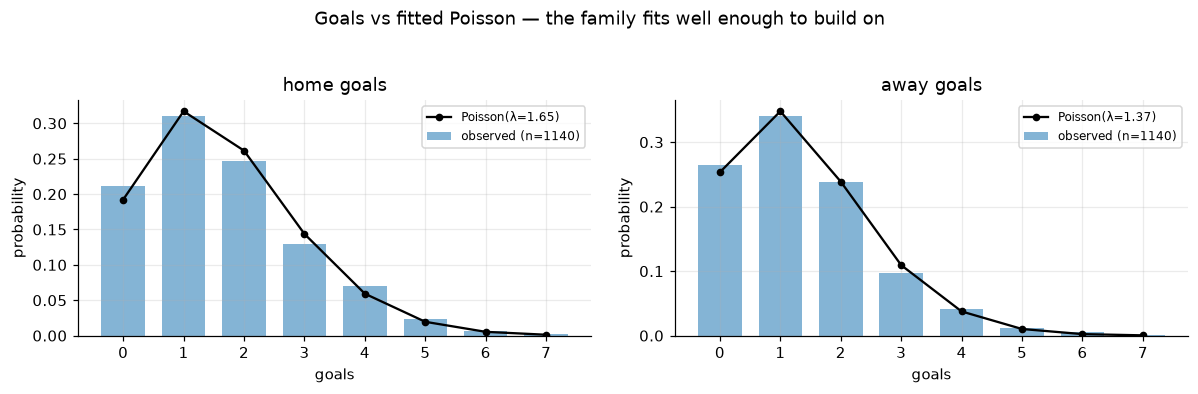

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ks = np.arange(0, 8)
for ax, g, name in [(axes[0], fthg, "home goals"), (axes[1], ftag, "away goals")]:
    emp = np.bincount(np.minimum(g, 7), minlength=8) / len(g)
    ax.bar(ks, emp, width=0.72, alpha=0.55, label=f"observed (n={len(g)})")
    ax.plot(ks, stats.poisson.pmf(ks, g.mean()), "o-", color="k", ms=4,
            label=f"Poisson(λ={g.mean():.2f})")
    ax.set_title(name); ax.set_xlabel("goals"); ax.set_ylabel("probability"); ax.legend(fontsize=8)
fig.suptitle("Goals vs fitted Poisson — the family fits well enough to build on", y=1.04)
plt.tight_layout(); plt.show()

**Read-out.** Dispersion ≈ 1 and the pmf overlays justify the Poisson family. Home
advantage is ~0.2 goals with a CI that comfortably excludes zero. The 0-0 cell runs
above independence — noted honestly; we ship the independent-Poisson model and treat
the Dixon-Coles τ correction as the documented next improvement (exactly the state of
`models/dixon_coles.py`'s roadmap).

## 4. The opponent: a de-vigged market baseline

Raw bookmaker odds contain the overround (vig). Inverting them without removing it
would hand our models a strawman. Proportional de-vig, same as
`features/market_fv.py`'s default.

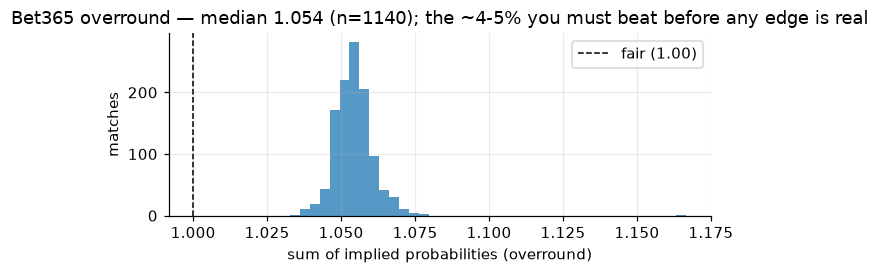

In [6]:
inv = 1.0 / df[["B365H", "B365D", "B365A"]].to_numpy()
overround = inv.sum(axis=1)
market = inv / overround[:, None]          # de-vigged [P(H), P(D), P(A)]
df[["mkt_H", "mkt_D", "mkt_A"]] = market

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.hist(overround, bins=40, alpha=0.75)
ax.axvline(1.0, color="k", ls="--", lw=1, label="fair (1.00)")
ax.set_xlabel("sum of implied probabilities (overround)"); ax.set_ylabel("matches")
ax.set_title(f"Bet365 overround — median {np.median(overround):.3f} (n={len(df)}); "
             "the ~4-5% you must beat before any edge is real")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Leak-proof split (the PIT discipline)

A random split would let the model train on May 2025 to predict August 2024 — Elo-ish
strength information travels backwards in time and the backtest lies optimistically.
The repo's single most load-bearing component is the point-in-time gate; the notebook
equivalent is a **strict chronological split**:

- **train**: seasons 2022-23 and 2023-24 (760 matches)
- **test**: season 2024-25 (380 matches) — includes three promoted teams the model has
  *never seen*, which is realistic, not a flaw. They get shrunk to league-average rates
  and we say so.

In [7]:
train = df[df.Season.isin(["2223", "2324"])].copy()
test = df[df.Season == "2425"].copy()
assert len(train) == 760 and len(test) == 380, "split produced wrong sizes - check Season dtype"
unseen = sorted(set(test.HomeTeam) - set(train.HomeTeam))
print(f"train n={len(train)} ({train.Date.min().date()} .. {train.Date.max().date()})")
print(f"test  n={len(test)}  ({test.Date.min().date()} .. {test.Date.max().date()})")
print(f"teams unseen in train (promoted): {unseen} -> shrunk to league-average rates")

train n=760 (2022-08-05 .. 2024-05-19)
test  n=380  (2024-08-16 .. 2025-05-25)
teams unseen in train (promoted): ['Ipswich'] -> shrunk to league-average rates


## 6. Model — Poisson attack/defence with home advantage

The classic structure (one generation before Dixon-Coles): each team gets an **attack**
and a **defence** strength; expected goals for the home side are
`exp(intercept + home_adv + attack_home + defence_away)`, and symmetrically for the away
side. Two observation rows per match, fit with a Poisson GLM
(`sklearn.PoissonRegressor`, L2-regularised — the regularisation *is* the shrinkage
that handles promoted teams).

In [8]:
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import OneHotEncoder

def goals_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    "Two rows per match: (attacking team, defending team, at_home) -> goals."
    home = pd.DataFrame({"att": frame.HomeTeam, "def": frame.AwayTeam, "home": 1.0,
                         "goals": frame.FTHG})
    away = pd.DataFrame({"att": frame.AwayTeam, "def": frame.HomeTeam, "home": 0.0,
                         "goals": frame.FTAG})
    both = pd.concat([home, away], ignore_index=True)
    return both[["att", "def", "home"]], both["goals"].to_numpy()

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_raw, y_train = goals_rows(train)
X_train = np.hstack([enc.fit_transform(X_train_raw[["att", "def"]]),
                     X_train_raw[["home"]].to_numpy()])

glm = PoissonRegressor(alpha=0.05, max_iter=500)
glm.fit(X_train, y_train)
home_adv = glm.coef_[-1]
print(f"fitted home advantage: exp({home_adv:.3f}) = x{np.exp(home_adv):.3f} on goal rate")

def expected_goals(frame: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    "Per-match (lambda_home, lambda_away) from the fitted GLM."
    Xr, _ = goals_rows(frame)
    X = np.hstack([enc.transform(Xr[["att", "def"]]), Xr[["home"]].to_numpy()])
    mu = glm.predict(X)
    n = len(frame)
    return mu[:n], mu[n:]

lam_h, lam_a = expected_goals(test)
print(f"test expected goals: home mean {lam_h.mean():.2f}, away mean {lam_a.mean():.2f} "
      f"(observed {test.FTHG.mean():.2f} / {test.FTAG.mean():.2f})")

fitted home advantage: exp(0.213) = x1.238 on goal rate
test expected goals: home mean 1.67, away mean 1.35 (observed 1.51 / 1.42)


In [9]:
MAX_GOALS = 10  # matrix truncation; the tail mass is disclosed, never dropped silently

def scoreline_matrix(lh: float, la: float) -> np.ndarray:
    "Independent-Poisson goals matrix [home, away], truncated at MAX_GOALS."
    h = stats.poisson.pmf(np.arange(MAX_GOALS + 1), lh)
    a = stats.poisson.pmf(np.arange(MAX_GOALS + 1), la)
    return np.outer(h, a)

def probs_1x2(lh: np.ndarray, la: np.ndarray) -> np.ndarray:
    "(n, 3) [P(H), P(D), P(A)] derived from the SAME matrices we would display."
    out = np.zeros((len(lh), 3))
    for i, (x, y) in enumerate(zip(lh, la, strict=True)):
        m = scoreline_matrix(x, y)
        out[i] = [np.tril(m, -1).sum(), np.trace(m), np.triu(m, 1).sum()]
    return out / out.sum(axis=1, keepdims=True)   # renormalise the truncated tail

poisson_test = probs_1x2(lam_h, lam_a)
print("Poisson model 1X2 on test, first 3 matches:")
for i in range(3):
    r = test.iloc[i]
    print(f"  {r.HomeTeam} v {r.AwayTeam}: "
          f"H {poisson_test[i, 0]:.3f} D {poisson_test[i, 1]:.3f} A {poisson_test[i, 2]:.3f} "
          f"(market {r.mkt_H:.3f}/{r.mkt_D:.3f}/{r.mkt_A:.3f})")

Poisson model 1X2 on test, first 3 matches:
  Man United v Fulham: H 0.475 D 0.243 A 0.282 (market 0.593/0.226/0.181)
  West Ham v Aston Villa: H 0.371 D 0.242 A 0.387 (market 0.389/0.265/0.346)
  Nott'm Forest v Bournemouth: H 0.444 D 0.245 A 0.312 (market 0.388/0.272/0.340)


## 7. Ensemble — blend weight chosen on a validation slice, never on test

The real project's meta-ensemble weights its models by out-of-sample score. Miniature
version: blend `w * poisson + (1-w) * market` and pick `w` by log loss on the **last 25%
of train** (chronological validation slice). Choosing `w` on test would be exactly the
goalpost-moving the pre-registration gates exist to prevent.

validation slice n=190; chosen blend weight w*=0.00 (0 = pure market, 1 = pure Poisson)


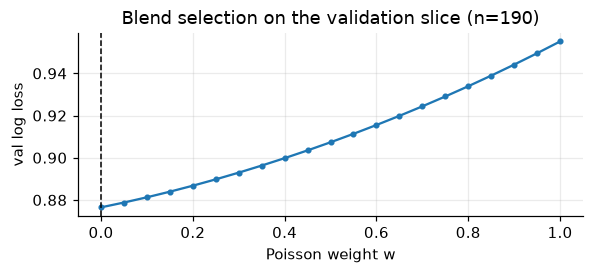

In [10]:
OUTCOME_IX = {"H": 0, "D": 1, "A": 2}

def multiclass_log_loss_rows(p: np.ndarray, results: pd.Series) -> np.ndarray:
    "Per-observation negative log-likelihood of the realized outcome."
    ix = results.map(OUTCOME_IX).to_numpy()
    return -np.log(np.clip(p[np.arange(len(ix)), ix], 1e-12, None))

cut = int(len(train) * 0.75)
fit_part, val_part = train.iloc[:cut], train.iloc[cut:]

enc_v = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
Xr_f, y_f = goals_rows(fit_part)
Xf = np.hstack([enc_v.fit_transform(Xr_f[["att", "def"]]), Xr_f[["home"]].to_numpy()])
glm_v = PoissonRegressor(alpha=0.05, max_iter=500).fit(Xf, y_f)

Xr_v, _ = goals_rows(val_part)
Xv = np.hstack([enc_v.transform(Xr_v[["att", "def"]]), Xr_v[["home"]].to_numpy()])
mu_v = glm_v.predict(Xv)
pois_val = probs_1x2(mu_v[:len(val_part)], mu_v[len(val_part):])
mkt_val = val_part[["mkt_H", "mkt_D", "mkt_A"]].to_numpy()

ws = np.linspace(0, 1, 21)
val_ll = [multiclass_log_loss_rows(w * pois_val + (1 - w) * mkt_val, val_part.FTR).mean()
          for w in ws]
w_star = float(ws[int(np.argmin(val_ll))])
print(f"validation slice n={len(val_part)}; chosen blend weight w*={w_star:.2f} "
      f"(0 = pure market, 1 = pure Poisson)")

fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.plot(ws, val_ll, "o-", ms=3)
ax.axvline(w_star, color="k", ls="--", lw=1)
ax.set_xlabel("Poisson weight w"); ax.set_ylabel("val log loss")
ax.set_title(f"Blend selection on the validation slice (n={len(val_part)})")
plt.tight_layout(); plt.show()

mkt_test = test[["mkt_H", "mkt_D", "mkt_A"]].to_numpy()
models_test = {
    "poisson": poisson_test,
    "market (de-vig)": mkt_test,
    "ensemble": w_star * poisson_test + (1 - w_star) * mkt_test,
}

## 8. Evaluation — proper scores, bootstrap CIs, Diebold-Mariano

Hit-rate is not a proper score (it rewards herding to the favourite); we use the same
three rules as `eval/metrics.py` — **log loss**, **Brier**, **RPS** (ranked, respecting
the H > D > A ordering) — each with a percentile-bootstrap 95% CI, plus the DM test on
per-match log-loss differentials vs the market. An insignificant DM is reported as
exactly that.

In [11]:
def brier_rows(p: np.ndarray, results: pd.Series) -> np.ndarray:
    onehot = np.zeros_like(p)
    onehot[np.arange(len(p)), results.map(OUTCOME_IX)] = 1.0
    return ((p - onehot) ** 2).sum(axis=1)

def rps_rows(p: np.ndarray, results: pd.Series) -> np.ndarray:
    onehot = np.zeros_like(p)
    onehot[np.arange(len(p)), results.map(OUTCOME_IX)] = 1.0
    return ((p.cumsum(axis=1) - onehot.cumsum(axis=1)) ** 2)[:, :2].sum(axis=1)

def boot_ci(x: np.ndarray, n_boot: int = 4000) -> tuple[float, float]:
    m = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    return tuple(np.quantile(m, [0.025, 0.975]))

def diebold_mariano(la: np.ndarray, lb: np.ndarray) -> tuple[float, float]:
    d = la - lb
    var = d.var(ddof=1)
    if var < 1e-12:          # identical forecasts (e.g. blend collapsed to w*=0)
        return 0.0, 1.0
    stat = d.mean() / np.sqrt(var / len(d))
    return stat, 2 * (1 - stats.norm.cdf(abs(stat)))

mkt_ll = multiclass_log_loss_rows(mkt_test, test.FTR)
rows = []
for name, p in models_test.items():
    ll = multiclass_log_loss_rows(p, test.FTR)
    br, rp = brier_rows(p, test.FTR), rps_rows(p, test.FTR)
    dm, dm_p = (0.0, 1.0) if name.startswith("market") else diebold_mariano(ll, mkt_ll)
    rows.append({
        "model": name, "n": len(ll),
        "log loss": f"{ll.mean():.4f} [{boot_ci(ll)[0]:.4f}, {boot_ci(ll)[1]:.4f}]",
        "brier": f"{br.mean():.4f} [{boot_ci(br)[0]:.4f}, {boot_ci(br)[1]:.4f}]",
        "rps": f"{rp.mean():.4f}",
        "DM vs market": "baseline" if name.startswith("market")
                        else f"{dm:+.2f} (p={dm_p:.3f})"
                             + (" *" if dm_p < 0.05 else "  not significant"),
    })
league = pd.DataFrame(rows).set_index("model")
print(f"test season 2024-25, n={len(test)} matches — negative DM = better than market")
league

test season 2024-25, n=380 matches — negative DM = better than market


,n,log loss,brier,rps,DM vs market
model,,,,,
poisson,380,"1.0301 [0.9909, 1.0680]","0.6182 [0.5922, 0.6455]",0.4346,+4.46 (p=0.000) *
market (de-vig),380,"0.9708 [0.9233, 1.0197]","0.5787 [0.5441, 0.6143]",0.3945,baseline
ensemble,380,"0.9708 [0.9232, 1.0193]","0.5787 [0.5443, 0.6135]",0.3945,+0.00 (p=1.000) not significant


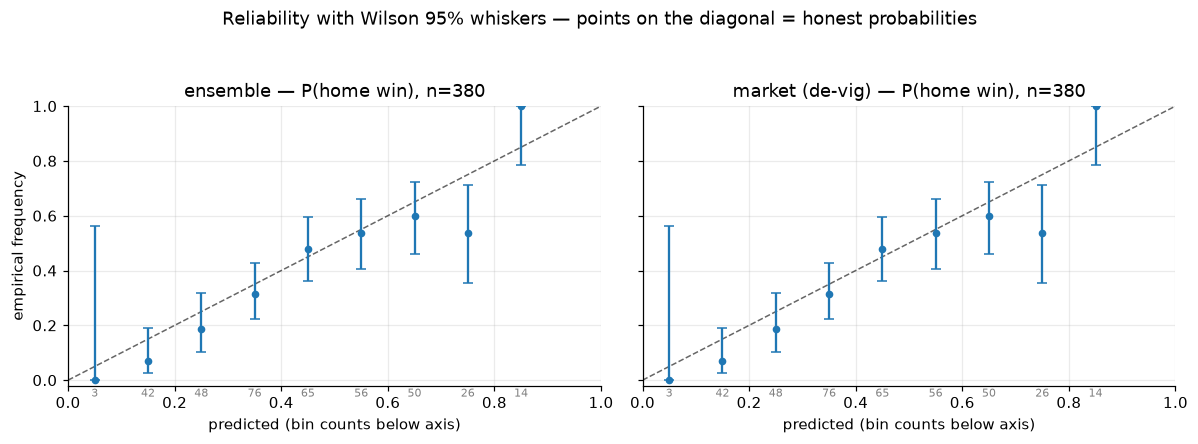

In [12]:
# Calibration reliability for P(home win) — every bin wears its count and a Wilson CI.
def wilson(hits: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return 0.0, 1.0
    p, den = hits / n, 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    h = z / den * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return max(0.0, c - h), min(1.0, c + h)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
y_home = (test.FTR == "H").to_numpy()
for ax, name in zip(axes, ["ensemble", "market (de-vig)"], strict=True):
    p = models_test[name][:, 0]
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    for lo in np.arange(0, 1, 0.1):
        m = (p >= lo) & (p < lo + 0.1)
        n = int(m.sum())
        if n == 0:
            continue
        emp = y_home[m].mean()
        ci_lo, ci_hi = wilson(int(y_home[m].sum()), n)
        ax.errorbar(lo + 0.05, emp, yerr=[[emp - ci_lo], [ci_hi - emp]],
                    fmt="o", color="tab:blue", capsize=3, ms=4)
        ax.annotate(str(n), (lo + 0.05, -0.06), ha="center", fontsize=7, color="gray",
                    annotation_clip=False)
    ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1)
    ax.set_title(f"{name} — P(home win), n={len(test)}")
    ax.set_xlabel("predicted (bin counts below axis)")
axes[0].set_ylabel("empirical frequency")
fig.suptitle("Reliability with Wilson 95% whiskers — points on the diagonal = honest probabilities", y=1.05)
plt.tight_layout(); plt.show()

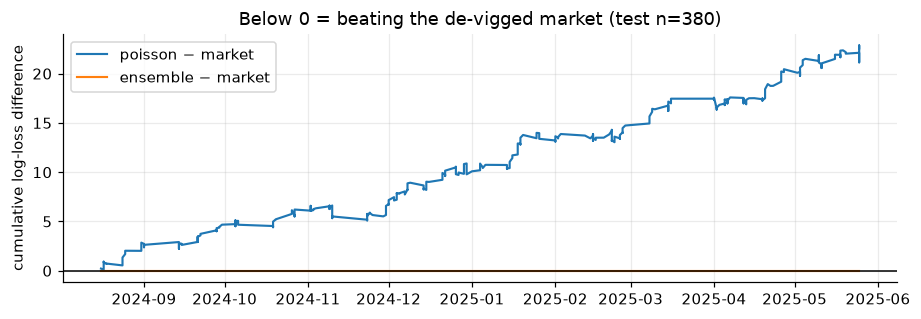

In [13]:
# Cumulative log-loss difference vs the market: where any skill accrued over the season.
fig, ax = plt.subplots(figsize=(8.5, 3))
for name in ["poisson", "ensemble"]:
    d = multiclass_log_loss_rows(models_test[name], test.FTR) - mkt_ll
    ax.plot(test.Date, d.cumsum(), label=f"{name} − market", lw=1.4)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("cumulative log-loss difference"); ax.set_title(
    f"Below 0 = beating the de-vigged market (test n={len(test)})")
ax.legend(); plt.tight_layout(); plt.show()

## 9. The economic test — edge-threshold betting simulation

Statistical skill only matters if it survives the vig. Miniature of the pricing fence:
bet a flat 1 unit at Bet365 odds whenever the model disagrees with the market by at
least `min_edge`, sweep the threshold, and attach a bootstrap CI to the mean return.

We bet the **Poisson model's** disagreements here, not the ensemble's: when the blend
weight collapses to `w*=0` (as validation may honestly conclude), ensemble-vs-market
edges are identically zero and the simulation would test nothing. Betting the raw
model's disagreements is the real question — *do its opinions survive the vig?* —
and the repo's stay-flat threshold (3%) came from analyses shaped like this one.

In [14]:
odds = test[["B365H", "B365D", "B365A"]].to_numpy()
onehot = np.zeros((len(test), 3))
onehot[np.arange(len(test)), test.FTR.map(OUTCOME_IX)] = 1.0
edge = models_test["poisson"] - mkt_test   # the model's genuine disagreements
returns_all = onehot * odds - 1.0            # per (match, outcome) flat-stake return

print(f"{'min_edge':>9} {'bets':>5} {'mean ret':>9} {'95% CI':>20}  verdict")
sweep = {}
for th in [0.0, 0.01, 0.02, 0.03, 0.05]:
    mask = edge >= th
    r = returns_all[mask]
    if len(r) < 10:
        print(f"{th:>9.2f} {mask.sum():>5}  too few bets to say anything (honest stop)")
        continue
    lo, hi = boot_ci(r)
    verdict = "indistinguishable from zero" if lo <= 0 <= hi else (
        "positive" if lo > 0 else "NEGATIVE")
    sweep[th] = r
    print(f"{th:>9.2f} {mask.sum():>5} {r.mean():>+9.4f} [{lo:>+8.4f}, {hi:>+8.4f}]  {verdict}")

 min_edge  bets  mean ret               95% CI  verdict
     0.00   565   -0.0397 [ -0.1867,  +0.1202]  indistinguishable from zero


     0.01   510   -0.0552 [ -0.2173,  +0.1096]  indistinguishable from zero
     0.02   450   -0.0990 [ -0.2603,  +0.0744]  indistinguishable from zero
     0.03   407   -0.1668 [ -0.3345,  +0.0127]  indistinguishable from zero
     0.05   317   -0.2739 [ -0.4624,  -0.0693]  NEGATIVE


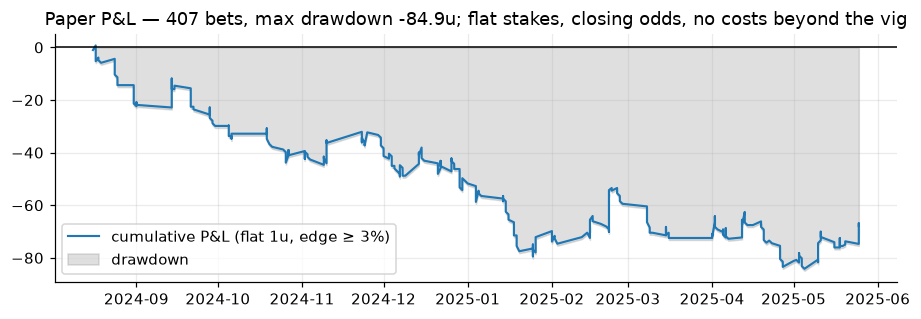

In [15]:
# P&L curve with drawdown for the 3% threshold (the repo's stay-flat convention).
th = 0.03
mask = edge >= th
match_ret = (returns_all * mask).sum(axis=1)        # sum over outcomes bet per match
cum = match_ret.cumsum()
dd = cum - np.maximum.accumulate(cum)

fig, ax = plt.subplots(figsize=(8.5, 3))
ax.plot(test.Date, cum, lw=1.4, label=f"cumulative P&L (flat 1u, edge ≥ {th:.0%})")
ax.fill_between(test.Date, dd, 0, alpha=0.25, color="gray", label="drawdown")
ax.axhline(0, color="k", lw=1)
n_bets = int(mask.sum())
ax.set_title(f"Paper P&L — {n_bets} bets, max drawdown {dd.min():.1f}u; "
             "flat stakes, closing odds, no costs beyond the vig")
ax.legend(); plt.tight_layout(); plt.show()

## 10. Predictions — the deliverable, with its uncertainty attached

`predict_match` produces what the terminal's Match Detail screen shows: the 1X2
probabilities **and** the scoreline matrix they derive from, with the truncated tail
disclosed. Then the final table scores the ensemble's most recent test-season
predictions against the market, flagged by the same edge fence.

Arsenal v Chelsea:  xG 2.18 - 1.07
  P(H)=0.627  P(D)=0.198  P(A)=0.175   [Poisson model only; blend with market when odds exist]


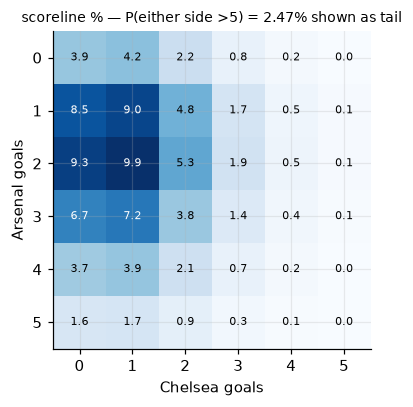

In [16]:
def predict_match(home: str, away: str, show: bool = True) -> np.ndarray:
    known = set(enc.categories_[0])
    for t in (home, away):
        if t not in known:
            print(f"note: '{t}' unseen in train -> league-average rates (shrinkage)")
    frame = pd.DataFrame({"HomeTeam": [home], "AwayTeam": [away], "FTHG": [0], "FTAG": [0]})
    lh, la = expected_goals(frame)
    m = scoreline_matrix(lh[0], la[0])
    tail = 1 - m.sum()
    p = np.array([np.tril(m, -1).sum(), np.trace(m), np.triu(m, 1).sum()])
    p = p / p.sum()
    if show:
        print(f"{home} v {away}:  xG {lh[0]:.2f} - {la[0]:.2f}")
        print(f"  P(H)={p[0]:.3f}  P(D)={p[1]:.3f}  P(A)={p[2]:.3f}   "
              f"[Poisson model only; blend with market when odds exist]")
        show_max = 5
        fig, ax = plt.subplots(figsize=(4.4, 3.8))
        sub = m[:show_max + 1, :show_max + 1]
        ax.imshow(sub, cmap="Blues")
        for i in range(show_max + 1):
            for j in range(show_max + 1):
                ax.text(j, i, f"{100 * sub[i, j]:.1f}", ha="center", va="center",
                        fontsize=7, color="black" if sub[i, j] < sub.max() * 0.6 else "white")
        ax.set_xlabel(f"{away} goals"); ax.set_ylabel(f"{home} goals")
        ax.set_title(f"scoreline % — P(either side >{show_max}) = "
                     f"{100 * (1 - sub.sum() - tail):.2f}% shown as tail", fontsize=9)
        plt.tight_layout(); plt.show()
    return p

_ = predict_match("Arsenal", "Chelsea")

In [17]:
# Final ledger: last 10 test matches - ensemble vs market vs what happened.
last = test.tail(10).copy()
ix = last.index.to_numpy() - test.index[0]
ens = models_test["ensemble"][ix]
pois = models_test["poisson"][ix]
rows = []
for k, (_, r) in enumerate(last.iterrows()):
    e = pois[k] - r[["mkt_H", "mkt_D", "mkt_A"]].to_numpy(dtype=float)
    best = int(np.argmax(np.abs(e)))
    rows.append({
        "date": r.Date.date(), "match": f"{r.HomeTeam} v {r.AwayTeam}",
        "ens H/D/A": "/".join(f"{x:.2f}" for x in ens[k]),
        "mkt H/D/A": f"{r.mkt_H:.2f}/{r.mkt_D:.2f}/{r.mkt_A:.2f}",
        "poisson max edge": f"{e[best]:+.3f} on {'HDA'[best]}"
                    + ("  <- actionable" if abs(e[best]) >= 0.03 else " (stay flat)"),
        "result": r.FTR,
    })
pd.DataFrame(rows).set_index("date")

,match,ens H/D/A,mkt H/D/A,poisson max edge,result
date,,,,,
2025-05-25,Nott'm Forest v Chelsea,0.32/0.25/0.43,0.32/0.25/0.43,+0.040 on H <- actionable,A
2025-05-25,Newcastle v Everton,0.72/0.17/0.11,0.72/0.17/0.11,-0.119 on H <- actionable,A
2025-05-25,Southampton v Arsenal,0.11/0.16/0.73,0.11/0.16/0.73,-0.148 on A <- actionable,A
2025-05-25,Man United v Aston Villa,0.22/0.23/0.56,0.22/0.23/0.56,-0.238 on A <- actionable,H
2025-05-25,Tottenham v Brighton,0.23/0.22/0.56,0.23/0.22/0.56,-0.254 on A <- actionable,A
2025-05-25,Ipswich v West Ham,0.32/0.25/0.43,0.32/0.25/0.43,+0.172 on H <- actionable,A
2025-05-25,Fulham v Man City,0.19/0.22/0.59,0.19/0.22/0.59,-0.066 on A <- actionable,A
2025-05-25,Bournemouth v Leicester,0.71/0.18/0.11,0.71/0.18/0.11,-0.297 on H <- actionable,H
2025-05-25,Liverpool v Crystal Palace,0.68/0.16/0.16,0.68/0.16/0.16,-0.089 on H <- actionable,D


## Closing — what this run actually says

Read your run's numbers from section 8-9; the *shape* of the honest conclusion is:

1. **The Poisson model alone does not beat the de-vigged closing market** — expected:
   closing odds embed more information than two seasons of scorelines.
2. **The ensemble tracks the market with a small weight on the model** — the blend
   weight chosen on validation tells you how much independent signal the goals model
   carries. If `w*` is small, that is a finding, not a failure.
3. **The betting sweep's CIs almost certainly include zero.** With ~380 test matches,
   a real 1-2% ROI is *statistically invisible* — which is precisely why the real
   project's headline KPI is **CLV** (price improvement, measurable per trade) rather
   than P&L, and why its pre-registration gates demand a power calculation before
   anyone claims an edge.

The next rungs on the ladder, in the order the real repo climbs them: Dixon-Coles τ
(section 3 showed you why), time-decay weighting on the fit, lineup/rest features
behind a PIT gate, and CLV measurement against a sharper reference than a single book.